This notebook will use a gradient of total water content to compute cloud base height and then compare with measurements from ceilometer.

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from glob import glob
import seaborn as sns
import string

In [2]:
apr = slice(dt.datetime(2020,4,10), dt.datetime(2020,4,20))
wrfout = xr.open_mfdataset(glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc")).sel(Time=apr)
wrfout["rho_air"] = wrfout.wrf.density_of_dry_air[:]
wrfout["air_temperature"] = wrfout.wrf.air_temperature[:]
wrfout["altitude"] =wrfout.wrf.altitude_asl_c[:]

/tmp/ipykernel_24164/4102662431.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Time' ('Time',) The recommendation is to set join explicitly for this case.
  wrfout = xr.open_mfdataset(glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc")).sel(Time=apr)
/tmp/ipykernel_24164/4102662431.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  wrfout = xr.open_mfdataset(glob("/mnt/data/model_output/ACI_OPT_2/*_mosaic.nc")).sel(

In [3]:
lwc = wrfout.QCLOUD * wrfout.rho_air
iwc = wrfout.QICE * wrfout.rho_air
swc = wrfout.QSNOW * wrfout.rho_air
gwc = wrfout.QGRAUP * wrfout.rho_air
water_content = xr.Dataset(
    coords={
        "Time": ("time", wrfout.Time.values),
        "bottom_top": ("bottom_top", wrfout.bottom_top.values),
        "j": ("j", wrfout.j.values),
        "i": ("i", wrfout.i.values),
    },
    data_vars={
        "lwc": (["time","bottom_top","j","i"], lwc.data),
        "iwc": (["time","bottom_top","j","i"], iwc.data),
        "swc": (["time","bottom_top","j","i"], swc.data),
        "gwc": (["time","bottom_top","j","i"], gwc.data),
        "altitude": (["time","bottom_top","j","i"], wrfout.altitude.data),
    }
)

In [4]:
wrfout_9pt = wrfout.mean(["i","j"])
wrfout_1pt = wrfout.isel(i=1,j=1)
water_content_9pt = water_content.mean(["i","j"])
water_content_1pt = water_content.isel(i=1,j=1)


In [5]:
def interp_1d(height, var, height_new):
    return np.interp(height_new, height, var)

def interp_zdim(ds, da_height_new):
    vars_to_interp = [v for v in ds.data_vars if v not in ["altitude","PH","PHB"]]
    ds_interp = xr.Dataset()
    for var in vars_to_interp:
        if "bottom_top" not in ds[var].dims:
            print(f"skipping {var} with no height coordinate")
            continue
        ds_interp[var] = xr.apply_ufunc(
            interp_1d,
            ds["altitude"],         # first arg: height profile
            ds[var],              # second arg: variable profile
            da_height_new,        # third arg: target heights
            input_core_dims=[["bottom_top"],["bottom_top"],["bottom_top"]],
            output_core_dims=[["bottom_top"]],
            vectorize=True,           # loop automatically over (sim, time)
            dask="parallelized",      # works with dask arrays
            keep_attrs="no_conflicts"
        )
    # add new height coordinate
    ds_interp = ds_interp.assign_coords({
        'height': (['bottom_top'], da_height_new.data)
    })
    return ds_interp

In [6]:
water_content_zinterp_9pt = interp_zdim(water_content_9pt, water_content_9pt.altitude.mean("time"))
water_content_zinterp_1pt = interp_zdim(water_content_1pt, water_content_1pt.altitude.mean("time")).compute()


In [69]:
water_content_zinterp_1pt["twc"] = water_content_zinterp_1pt.lwc+water_content_zinterp_1pt.iwc
dLdz = water_content_zinterp_1pt.twc.differentiate("height")
gradient_thresh = 1e-7    # 0.1 g m-3 m-1
twc_thresh = 1e-7         # 0.1 g m-3

# vertically varying threshold from McCusker
twc_thresh_z = xr.DataArray(
    coords={"height":[0,1000,4000,5000]},
    data=[1e-6, 1e-6, 1e-7, 1e-7]
)
twc_thresh_z = twc_thresh_z.interp(
    coords=dict(height=water_content_1pt.altitude.mean("time")),
    kwargs=dict(fill_value="extrapolate")
).compute()



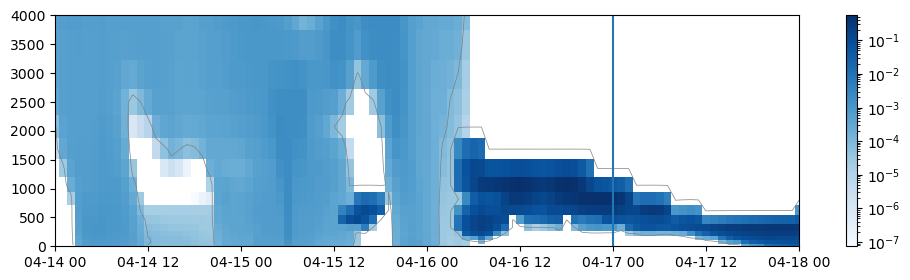

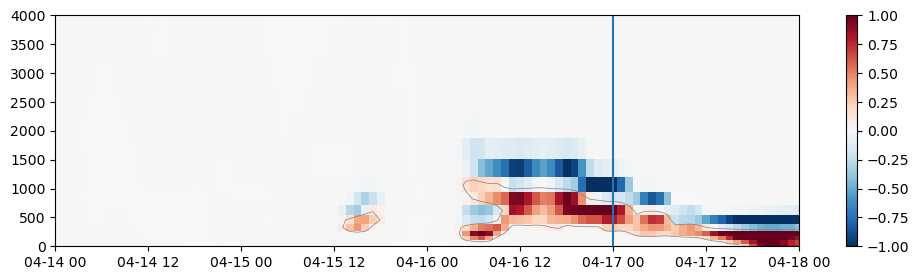

In [70]:
ymax = 4000

fig = plt.figure(figsize=(12,3))
plot = plt.pcolormesh(
    water_content_zinterp_1pt.Time,
    water_content_zinterp_1pt.height,
    1000*water_content_zinterp_1pt.twc.T,
    cmap="Blues",
    norm=matplotlib.colors.LogNorm()
)
c = plt.contour(
    water_content_zinterp_1pt.Time,
    water_content_zinterp_1pt.height,
    (water_content_zinterp_1pt.twc.T),
    levels=[twc_thresh],
    colors="grey",
    linewidths=0.5
)
plt.colorbar(plot)

plt.ylim(0,ymax)
plt.xlim(dt.datetime(2020,4,14), dt.datetime(2020,4,18))
plt.axvline(x=dt.datetime(2020,4,17))

fig = plt.figure(figsize=(12,3))
plot = plt.pcolormesh(
    water_content_zinterp_1pt.Time,
    water_content_zinterp_1pt.height,
    1e6*dLdz.T,
    cmap="RdBu_r",
    vmin=-1,vmax=1
)
c = plt.contour(
    water_content_zinterp_1pt.Time,
    water_content_zinterp_1pt.height,
    (dLdz.T),
    levels=[gradient_thresh],
    colors="grey",
    linewidths=0.5
)
plt.colorbar(plot)

plt.ylim(0,ymax)
plt.xlim(dt.datetime(2020,4,14), dt.datetime(2020,4,18))
plt.axvline(x=dt.datetime(2020,4,17))



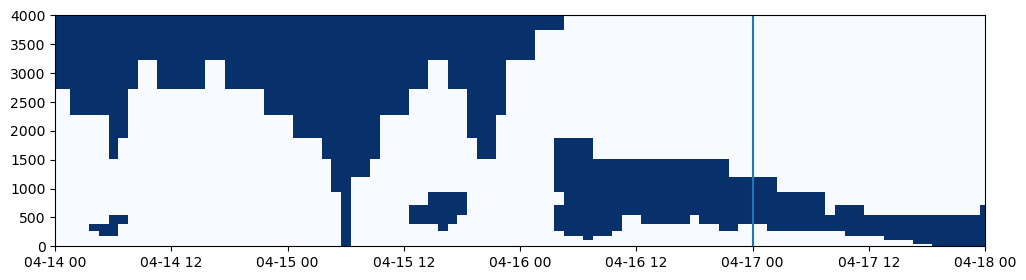

In [71]:
fig = plt.figure(figsize=(12,3))
plot = plt.pcolormesh(
    water_content_zinterp_1pt.Time,
    water_content_zinterp_1pt.height,
    (water_content_zinterp_1pt.twc>twc_thresh_z).T,
    cmap="Blues",
)


plt.ylim(0,ymax)
plt.xlim(dt.datetime(2020,4,14), dt.datetime(2020,4,18))
plt.axvline(x=dt.datetime(2020,4,17))


# Read ceilometer measurements

In [72]:
files = "/mnt/data/mosaic/ceilometer/*.nc"
ceil = xr.open_mfdataset(files)
ceil

/tmp/ipykernel_24164/2329237996.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ceil = xr.open_mfdataset(files)


<xarray.Dataset> Size: 69MB
Dimensions:                 (time: 21601, bound: 2, range: 252)
Coordinates:
  * time                    (time) datetime64[ns] 173kB 2020-04-14T00:00:01 ....
  * range                   (range) float32 1kB 15.0 45.0 ... 7.545e+03
Dimensions without coordinates: bound
Data variables: (12/34)
    base_time               (time) datetime64[ns] 173kB 2020-04-14 ... 2020-0...
    time_offset             (time) datetime64[ns] 173kB dask.array<chunksize=(5401,), meta=np.ndarray>
    time_bounds             (time, bound) datetime64[ns] 346kB dask.array<chunksize=(5401, 2), meta=np.ndarray>
    range_bounds            (time, range, bound) float32 44MB dask.array<chunksize=(5401, 252, 2), meta=np.ndarray>
    detection_status        (time) float32 86kB dask.array<chunksize=(5401,), meta=np.ndarray>
    status_flag             (time) float32 86kB dask.array<chunksize=(5401,), meta=np.ndarray>
    ...                      ...
    backscatter             (time, range) float32 22MB dask.array<chunksize=(5401, 252), meta=np.ndarray>
    measurement_parameters  (time) |S12 259kB dask.array<chunksize=(5401,), meta=np.ndarray>
    status_string           (time) |S12 259kB dask.array<chunksize=(5401,), meta=np.ndarray>
    lat                     (time) float32 86kB -9.999e+03 ... -9.999e+03
    lon                     (time) float32 86kB -9.999e+03 ... -9.999e+03
    alt                     (time) float32 86kB -9.999e+03 ... -9.999e+03
Attributes: (12/27)
    command_line:                ceil_ingest -s mos -f M1
    Conventions:                 ARM-1.0
    process_version:             ingest-ceil-1.6-0.el7
    dod_version:                 ceil-b1-2.1
    input_source:                /data/collection/mos/mosceilM1.00/20041400.DAT
    site_id:                     mos
    ...                          ...
    qc_bit_1_assessment:         Bad
    qc_bit_2_description:        Value is less than the valid_min.
    qc_bit_2_assessment:         Bad
    qc_bit_3_description:        Value is greater than the valid_max.
    qc_bit_3_assessment:         Bad
    history:                     created by user dsmgr on machine flint at 20...

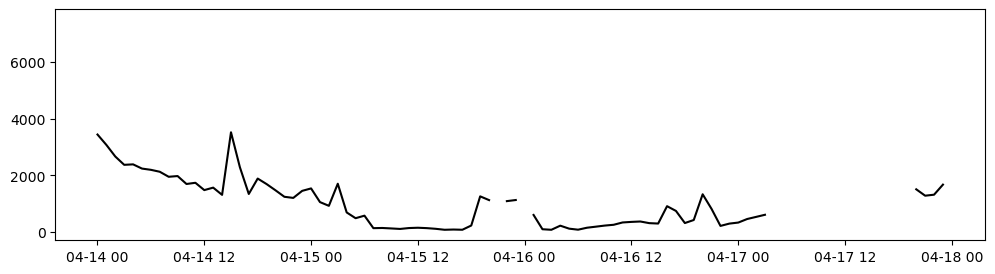

In [73]:
ceil_1h = ceil.resample(time="1h").mean()

fig = plt.figure(figsize=(12,3))
plt.plot(ceil_1h.time, ceil_1h.first_cbh, "k")


# Calculate cloud base height from total liquid water content threshold

In [74]:
k_base_height = np.full(water_content_zinterp_1pt.Time.shape, -1.)
twc = water_content_zinterp_1pt.twc
for i in range(len(twc.time)):
    L_profile = twc.isel(time=i)
    cloud = L_profile.where(L_profile>=twc_thresh, drop=True)
    if len(cloud):
        k_base_height[i] = np.ma.amin(cloud.bottom_top.values)
    else:
        k_base_height[i] = np.nan

base_height_twc_inds = xr.DataArray(
    coords={"Time": water_content_zinterp_1pt.Time.values,},
    data=k_base_height.astype(int)
)

/tmp/ipykernel_24164/3264235466.py:13: RuntimeWarning: invalid value encountered in cast
  data=k_base_height.astype(int)


In [75]:
k_base_height_zthresh = np.full(water_content_zinterp_1pt.Time.shape, -1.)
for i in range(len(twc.time)):
    L_profile = twc.isel(time=i)
    cloud = L_profile.where(L_profile>=twc_thresh_z, drop=True)
    if len(cloud):
        k_base_height_zthresh[i] = np.ma.amin(cloud.bottom_top.values)
    else:
        k_base_height_zthresh[i] = np.nan

base_height_twcz_inds = xr.DataArray(
    coords={"Time": water_content_zinterp_1pt.Time.values,},
    data=k_base_height_zthresh.astype(int)
)


/tmp/ipykernel_24164/736632265.py:12: RuntimeWarning: invalid value encountered in cast
  data=k_base_height_zthresh.astype(int)


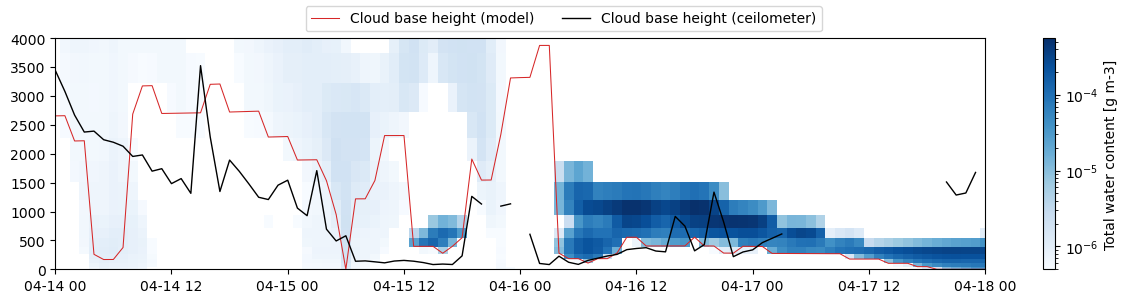

In [ ]:
cmap = matplotlib.cm.Blues
cmap.set_under("white")

fig = plt.figure(figsize=(15,3))
plot = plt.pcolormesh(
    water_content_zinterp_1pt.Time,
    water_content_zinterp_1pt.height,
    (water_content_zinterp_1pt.iwc+water_content_zinterp_1pt.lwc).T,
    cmap=cmap,
    norm=matplotlib.colors.LogNorm(vmin=0.5e-6)
)

cbar = plt.colorbar(plot, label="Total water content [g m-3]")

plt.plot(
    water_content_zinterp_1pt.Time,
    wrfout_1pt.wrf.altitude_asl.isel(bottom_top_stag=base_height_twcz_inds),
    color="tab:red",
    linewidth=0.75,
    label="Cloud base height (model)"
)

plt.plot(ceil_1h.time, ceil_1h.first_cbh, color="k", linewidth=1, label="Cloud base height (ceilometer)")


plt.ylim(0,4000)
plt.xlim(dt.datetime(2020,4,14), dt.datetime(2020,4,18))
fig.legend(ncols=2, loc="upper center")

plt.savefig("../figures/cloud_base_height.png", bbox_inches="tight")


Above: time series of cloud base height from ceilometer (black) and calculated from model outout (red). The total water path output used to calculate the base height is also shown.

We can discuss four distinct periods here:

Period 1, up to ~2020-04-15 09:00
- ceilometer shows slowly descending cloud base height, reaching few 100 m when liquid clouds form at onset of event
- model qualitatively captures this behaviour with some variability

Period 2, 2020-04-15 09:00 - 18:00
- ceilometer shows a base height of a few hundred metres, corresponding to low level liquid clouds
- model predicts a liquid cloud that is too high by about 250 m and with a delayed onset by about 3 hours

Perdio 3, 2020-04-15 18:00 - 2020-04-16 ~00:00
- ceilometer base height rises again although the signal is disrupted. This period was associated with precipitation
- the model again qualitatively captures this behaviour in the cloud base height time series although it is not clear whether the liquid precip would be captured here

Period 4, 2020-04-16 00:00 - 2020-04-17 00:00
- ceilometer height decreases again to around few 100 m, slowly rising to about 500 m by the end of the day, with some variability, again corresponding to low level liquid clouds near the surface
- after a peak in cloud base height for the first few hours as the base of the ice cloud lifts, the model predicts low level liquid clouds and achieves a good agreement with the cloud base height measurements.